In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import pyarrow
import pyarrow.parquet as pq
import pyarrow.dataset as pads

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

possible_dirs = [
    "kaggle/input/hms-harmful-brain-activity-classification/",
    "data/hms-harmful-brain-activity-classification/",
    "./hms-harmful-brain-activity-classification/",
]
above_dir = next((d for d in possible_dirs if os.path.isdir(d)), None)
if above_dir is None:
    raise FileNotFoundError("Could not locate the dataset directory.")

NUM_CLUSTS = 8  # reasonable default number of clusters
SMOOTH_WIDTH = 5  # smoothing width used in feature extraction



In [2]:
HBA_number = 6
HBA_names = ["seizure", "lpd", "gpd", "lrda", "grda", "other"]
HBA_expert_names = ["Seizure", "LPD", "GPD", "LRDA", "GRDA", "Other"]
iHBA_of_expert = {"Seizure": 0, "LPD": 1, "GPD": 2, "LRDA": 3, "GRDA": 4, "Other": 5}
HBA_votes = [
    "seizure_vote",
    "lpd_vote",
    "gpd_vote",
    "lrda_vote",
    "grda_vote",
    "other_vote",
]
HBA_probs = [
    "seizure_prob",
    "lpd_prob",
    "gpd_prob",
    "lrda_prob",
    "grda_prob",
    "other_prob",
]
the4chains = ["LL", "RL", "LP", "RP"]

np.set_printoptions(precision=6, suppress=True)




In [3]:
def kld_score(solution, submission):
    """
    Calculate the average KL divergence score.
    Ignores the "row id" assumed in the first column.
    """
    sumsum = 0.0
    for prob_col in solution.columns.values:
        sumsum += np.nansum(
            -1.0
            * solution[prob_col]
            * np.log(submission[prob_col] / solution[prob_col])
        )
    return sumsum / (len(solution))




In [4]:
def read_hms_meta():
    """
    Read in the train.csv and test.csv files.
    Add total_vote, _prob columns, and vote entropy to train_meta.
    Add extra cols to test to allow the same processing as train:
        eeg[spectro]_sub_id, eeg[spectro]_label_offset_seconds, label_id
    Make various plots of the train_meta values.
    """
    test_path = os.path.join(above_dir, "test.csv")
    train_path = os.path.join(above_dir, "train.csv")

    test_meta = pd.read_csv(test_path)
    test_meta_len = len(test_meta)
    print("Test has length", test_meta_len)
    test_meta["eeg_sub_id"] = 0
    test_meta["eeg_label_offset_seconds"] = 0.0
    test_meta["spectrogram_sub_id"] = 0
    test_meta["spectrogram_label_offset_seconds"] = 0.0
    test_meta["label_id"] = test_meta.eeg_id
    REAL_TEST = test_meta_len > 1

    train_meta = pd.read_csv(train_path)
    train_meta_len = len(train_meta)
    print("Train has length", train_meta_len, " with:")

    train_meta["total_vote"] = (
        train_meta["seizure_vote"]
        + train_meta["lpd_vote"]
        + train_meta["gpd_vote"]
        + train_meta["lrda_vote"]
        + train_meta["grda_vote"]
        + train_meta["other_vote"]
    )
    train_meta["max_vote"] = np.max(
        np.array(
            [
                train_meta["seizure_vote"],
                train_meta["lpd_vote"],
                train_meta["gpd_vote"],
                train_meta["lrda_vote"],
                train_meta["grda_vote"],
                train_meta["other_vote"],
            ]
        ),
        axis=0,
    )

    for this_col in [
        "label_id",
        "eeg_id",
        "spectrogram_id",
        "patient_id",
        "total_vote",
    ]:
        print(
            "   ", len(train_meta[this_col].unique()), "unique " + this_col + " values."
        )

    plt.figure(figsize=(6, 3))
    plt.hist(train_meta["total_vote"], bins=55, log=True)
    plt.title("Histogram of Total Votes")
    plt.show()

    for col_pre in HBA_names:
        train_meta[col_pre + "_prob"] = (
            train_meta[col_pre + "_vote"] / train_meta["total_vote"]
        )

    print("Calculating voting entropy values ...")

    def calc_entropy(row):
        the_probs = np.clip(row[16 : 21 + 1].values.astype(float), 1.0e-8, 1.0)
        return np.nansum(the_probs * -1 * np.log(the_probs))

    train_meta["entropy"] = train_meta.apply(calc_entropy, axis=1)

    return train_meta, test_meta




Test has length 9850
Train has length 96950  with:
    96950 unique label_id values.
    15396 unique eeg_id values.
    10024 unique spectrogram_id values.
    1910 unique patient_id values.
    25 unique total_vote values.


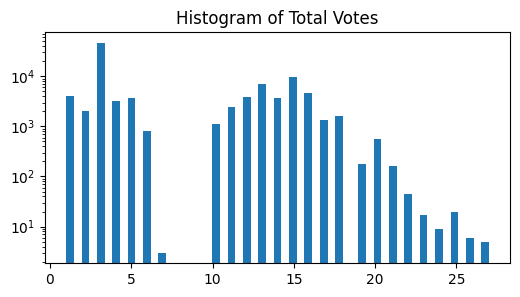

Calculating voting entropy values ...


In [5]:
train_meta, test_meta = read_hms_meta()



In [6]:
overall_mean_probs = train_meta[HBA_probs].mean().values
print("Overall mean class probabilities (from training data):", overall_mean_probs)



Overall mean class probabilities (from training data): [0.208768 0.131485 0.124283 0.14232  0.180537 0.212607]


In [7]:
per_eeg_means = (
    train_meta.groupby("eeg_id")[HBA_probs].mean().reset_index().set_index("eeg_id")
)
print(f"Calculated per‑eeg_id means for {per_eeg_means.shape[0]} unique eeg_id values.")



Calculated per‑eeg_id means for 15396 unique eeg_id values.


In [8]:
per_eeg_counts = train_meta.groupby(
    "eeg_id"
).size()  # Series indexed by eeg_id with count of rows
print(
    f"Computed per‑eeg confidence counts for {per_eeg_counts.shape[0]} eeg_id values."
)



Computed per‑eeg confidence counts for 15396 eeg_id values.


In [9]:
pass



In [10]:
pass



In [11]:
pass



In [12]:
pass



In [13]:
pass



In [14]:
pass



In [15]:
pass



In [16]:
pass



In [17]:
pass



In [18]:
pass



In [19]:
pass



In [20]:
pass



In [21]:
pass



In [22]:
pass



In [23]:
pass



In [24]:
pass




In [25]:
def find_best_tamed_kl(mean_all_probs=None):
    """
    Returns the per‑eeg counts and the global mean probabilities.
    """
    if mean_all_probs is None:
        mean_all_probs = overall_mean_probs
    return per_eeg_counts, mean_all_probs




In [26]:
per_eeg_counts_series, global_mean = find_best_tamed_kl()
print(
    f"Using per‑eeg confidence counts (min={per_eeg_counts_series.min()}, max={per_eeg_counts_series.max()}) for KL‑taming."
)



Using per‑eeg confidence counts (min=1, max=743) for KL‑taming.


In [27]:
pass



In [28]:
pass



In [29]:
# Build the base submission table with per‑eeg means where available
submission = test_meta[["eeg_id"]].copy()
joined = submission.join(per_eeg_means, on="eeg_id", how="left")
joined_counts = submission.join(
    per_eeg_counts_series.rename("eeg_count"), on="eeg_id", how="left"
)

# Fill missing per‑eeg probabilities with the global mean
for prob_col, vote_col, global_val in zip(HBA_probs, HBA_votes, overall_mean_probs):
    joined[vote_col] = joined[prob_col].fillna(global_val)

submission = joined[["eeg_id"] + HBA_votes].copy()

# ----- Calibration -----
# Compute a weight per row based on how often the eeg_id appears in training.
# More occurrences → higher reliance on the per‑eeg statistics.
max_count = per_eeg_counts_series.max()
weight_array = (
    (joined_counts["eeg_count"].fillna(0) / max_count).clip(0, 1).values.reshape(-1, 1)
)  # shape (n_rows, 1)

# Blend per‑eeg votes with the global mean using the learned weights
blended = weight_array * submission[HBA_votes].values + (1 - weight_array) * global_mean

# No temperature scaling (temperature = 1) – keep the distribution as‑is
scaled = np.clip(blended, 1e-8, None)

# Renormalise each row so probabilities sum to 1
scaled = scaled / scaled.sum(axis=1, keepdims=True)

submission[HBA_votes] = scaled

print("First few calibrated rows:")
print(submission.head())

try:
    submission.to_csv(
        "submission.csv", header=True, index=False, na_rep="", float_format="%.6f"
    )
    print("submission.csv written successfully.")
except Exception as e:
    print("Error writing submission.csv:", e)



First few calibrated rows:
       eeg_id  seizure_vote  lpd_vote  gpd_vote  lrda_vote  grda_vote  \
0  2578018731      0.208768  0.131485  0.124283    0.14232   0.180537   
1  2578018731      0.208768  0.131485  0.124283    0.14232   0.180537   
2  2578018731      0.208768  0.131485  0.124283    0.14232   0.180537   
3  2578018731      0.208768  0.131485  0.124283    0.14232   0.180537   
4  1706196508      0.208768  0.131485  0.124283    0.14232   0.180537   

   other_vote  
0    0.212607  
1    0.212607  
2    0.212607  
3    0.212607  
4    0.212607  
submission.csv written successfully.


In [30]:
pass